# **Coastal Water Temperature Final Station Graphics**

Written by Bailey Armos - [bailey.armos@noaa.gov](bailey.armos@noaa.gov)

Coastal Hazards Branch  
Oceanographic Division  
NOAA's Center for Operational Oceanographic Products and Services (CO-OPS)

Last updated on: 4/21/2025

## Overview
NOAA's CO-OPS collects trusted coastal data—including water temperature, tides, and currents—that helps keep navigation safe, supports commerce, and protects coastal communities and ecosystems. Since the early 1990s, over 220 water temperature sensors have been installed along U.S. coasts and in the Great Lakes. CO-OPS did an in-depth analysis on 174 stations with at least 20 years of data. An automated quality control system was developed to streamline data processing, flagging suspect data, and calculating daily averages. Manual reviews also caught sensor drifts at 47 stations, ensuring the data is reliable for long-term research.

## Prerequisites and running the Notebook
This notebook uses Python programming and users may run it either in **Google Colab** or **Jupyter Notebook**. To work offline, manage libraries and dependencies personally; using **Jupyter Notebook** is recommended. If you want cloud-based instant access, seamless co-operation and have access to good internet connection, **Google Colab** is the best option.

This notebook is designed so that people with limited familiarity with Python can run the notebook. To do so, go to the [github](https://github.com/NOAA-CO-OPS/coastal-water-temperature) page and click on the drop down menu under 'Code', then download the ZIP file. Extract the ZIP file and upload the Coastal_temp_final_station_graphics into [google colab](https://colab.research.google.com/). [Explore different station/s](https://tidesandcurrents.noaa.gov) and change the station variable in step 3. There is also an option to run through all of the station. The code creates a folder called "Daily_Water_Final_Plots" in your working directory for storing the created graphics. Lastly, click **Runtime** in the top menu and choose **Run All**. Then, when the 'Choose Files' box in step 2 becomes active, click on it and upload the Daily_Water_flagged_dates.zip and station_region_list. You will see a green check mark to the left of each cell as cells are sucessfully executed.

Users should be prepared to commit 30 minutes to familiarize themselves with the notebook, upload data, run code and examine results.

## Learning Outcomes
In this notebook users will be able to:
  1. Explore daily averaged water temperature data at over 100 stations
  2. Plot and save different figures that represent each stations including a time series plot, a residual plot, an average seasonal cycle plot, a seasonal cycle over the years plot, and a heatmap.

  ## Data Sources and Documentation

  All data comes from CO-OPS's sensors. Stations with water temperature data can be found via [CO-OPS Metadata API](https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations.json?type=watertemp). 6-min water temperature data can be accessed through [CO-OPS Data API](https://api.tidesandcurrents.noaa.gov/api/prod/).
  
  The QA/QCed daily water temperature data is currently available on github with this notebook. Each station’s data is provided in a separate comma-separated values (CSV) file, containing daily means, residuals, and quality control (QC) flags. Each CSV includes the following columns: Date, DAILY_WATER_TEMP, residual, manual_flag, automated_flag, and data_fill_flag. Suspect data in the manual and automated flag columns are marked with a “1,” while data that passed QC remain unflagged. The data_fill_flag column indicates the source of any replacement data (e.g., DCP2 E1, DCP3 E1, DCP1 E2) on the dates it was used, while unfilled data have no entry in this column.

  ## Software
  This tutorial uses the following Python packages
  - pandas
  - matplotlib
  - datetime
  - os
  - zipfile
  - calplot
  - numpy
  - warnings


## **Step 1**
## Install and Load Packages
Lets check if you have these packages installed. If not, this cell will install them.

In [1]:
# @title
import subprocess, sys
packages = ["pandas","matplotlib","datetime","calplot","numpy"]
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import os
import zipfile
import calplot
import numpy as np
#comment the line below if using Jupyter Notebook
from google.colab import files
#remove associated warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

## **Step 2**
## Upload Data
Here we will upload the Daily_Water_flagged_dates.zip and the station_region_list.csv. These files can be found on the CO-OPS [Github](https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks/tree/main/Coastal_Water_Temperature) page in the Coastal_Hazards_Example_Notebooks repository with this notebook.

In [3]:
#@title Upload Daily Water Temperature Data

#this can take a few minuates to load

uploaded = files.upload()

Saving daily_flagged_water_temperature_data.zip to daily_flagged_water_temperature_data.zip
Saving station_region_list.csv to station_region_list.csv


In [5]:
# Unzip the uploaded file
zip_file = "daily_flagged_water_temperature_data.zip"  # Replace with your file name
extract_to = "/content"  # Specify the folder to extract to

# Create target directory if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Files unzipped to {extract_to}")

Files unzipped to /content


In [6]:
path = 'daily_flagged_water_temperature_data/'

station_df = pd.read_csv('station_region_list.csv')
station_list = station_df['Station ID'].unique()
station_list

array([1611400, 1612340, 1612480, 1615680, 1617433, 1617760, 1619910,
       1630000, 1770000, 1820000, 1890000, 2695540, 8410140, 8413320,
       8418150, 8443970, 8447386, 8447930, 8449130, 8452660, 8452944,
       8454000, 8454049, 8461490, 8465705, 8467150, 8510560, 8516945,
       8518750, 8519483, 8531680, 8534720, 8536110, 8537121, 8539094,
       8540433, 8545240, 8548989, 8551762, 8551910, 8555889, 8557380,
       8571421, 8571892, 8573364, 8573927, 8574680, 8577330, 8594900,
       8631044, 8632200, 8635750, 8637689, 8638610, 8638863, 8639348,
       8651370, 8652587, 8656483, 8658120, 8658163, 8661070, 8665530,
       8670870, 8720030, 8720218, 8721604, 8723214, 8723970, 8724580,
       8725110, 8725520, 8726520, 8726724, 8727520, 8728690, 8729108,
       8729210, 8729840, 8735180, 8760922, 8761724, 8762482, 8768094,
       8770475, 8770570, 8770613, 8770971, 8771013, 8771341, 8771450,
       8771510, 8771972, 8773037, 8773259, 8773701, 8774770, 8775237,
       8775283, 8775

## **Step 3**
## Here we choose the station of interest or can run through and save plots for every station

In [7]:
# @title Run and output all station graphics or choose one station to plot below

station_choice = input('Option single or all ')
if station_choice == 'single':
  station_selection = input('Input station ID ')

Option single or all single
Input station ID 9759110


## **Step 4**

- Read the csv file
- Remove flagged data
- Plot and save graphics

9759110
Missing Timestamps:
DatetimeIndex(['1970-01-01'], dtype='datetime64[ns]', freq='D')


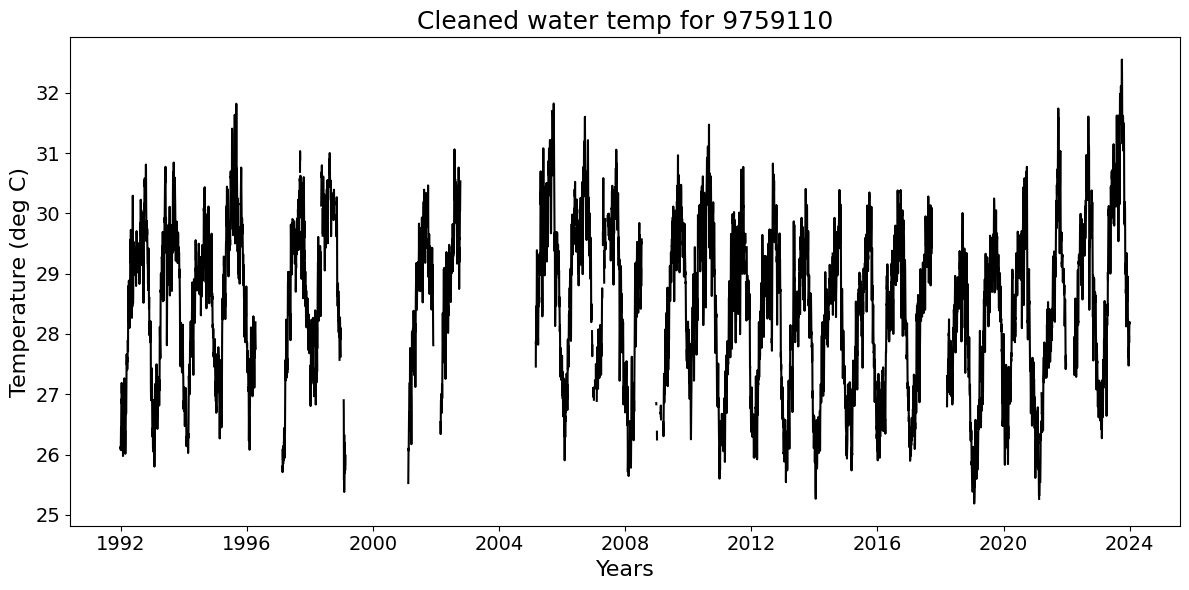

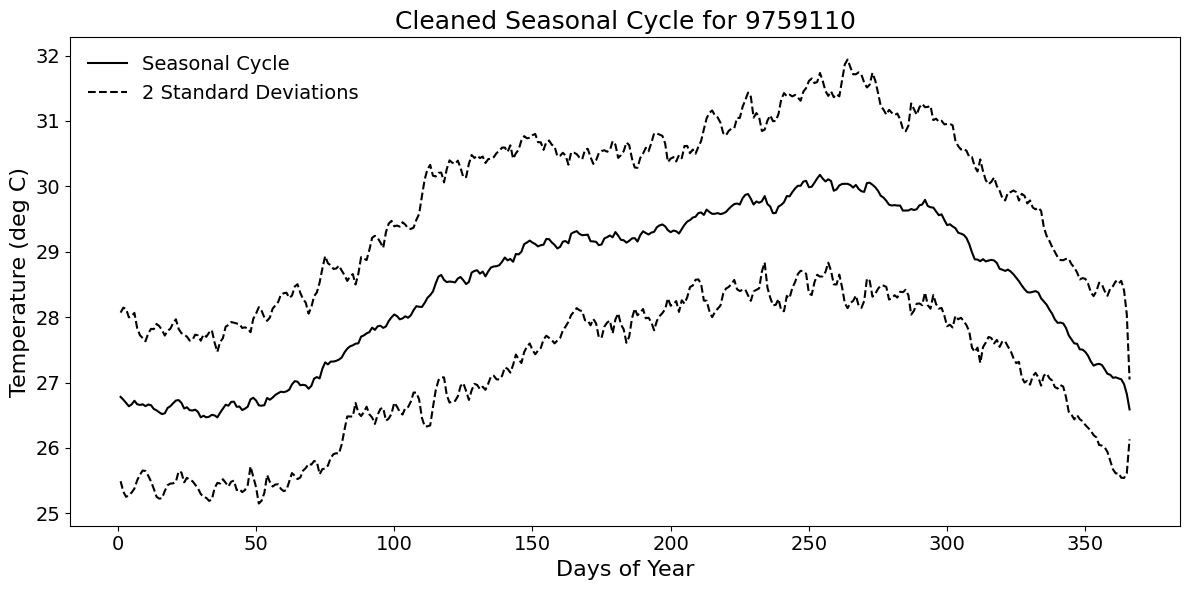

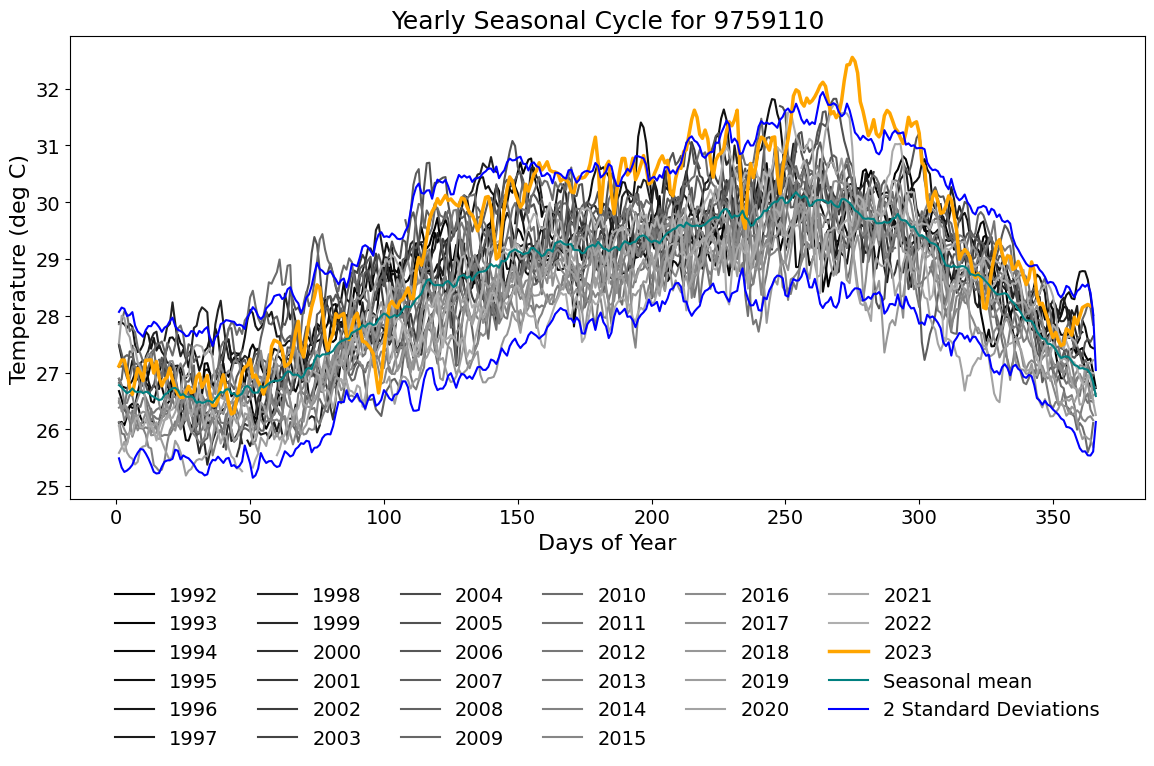

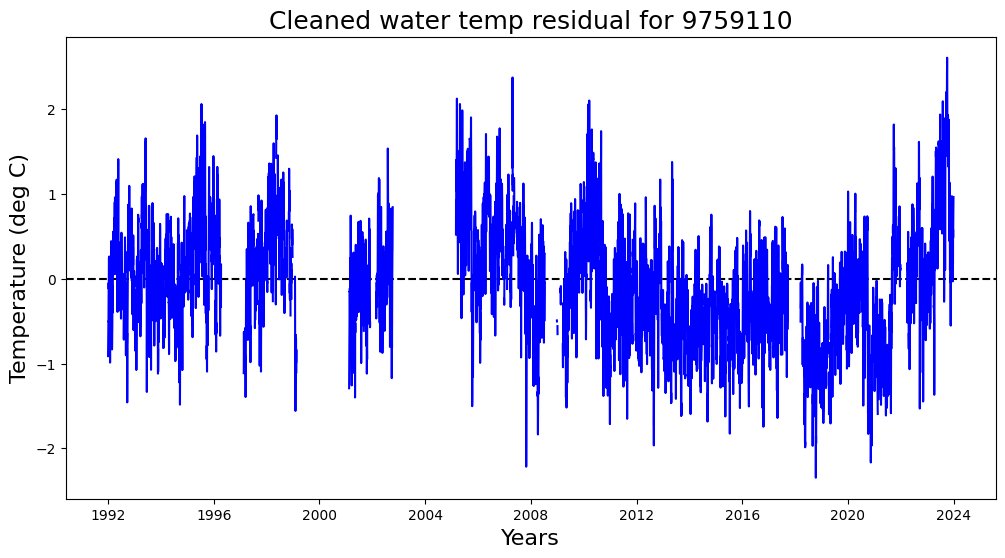

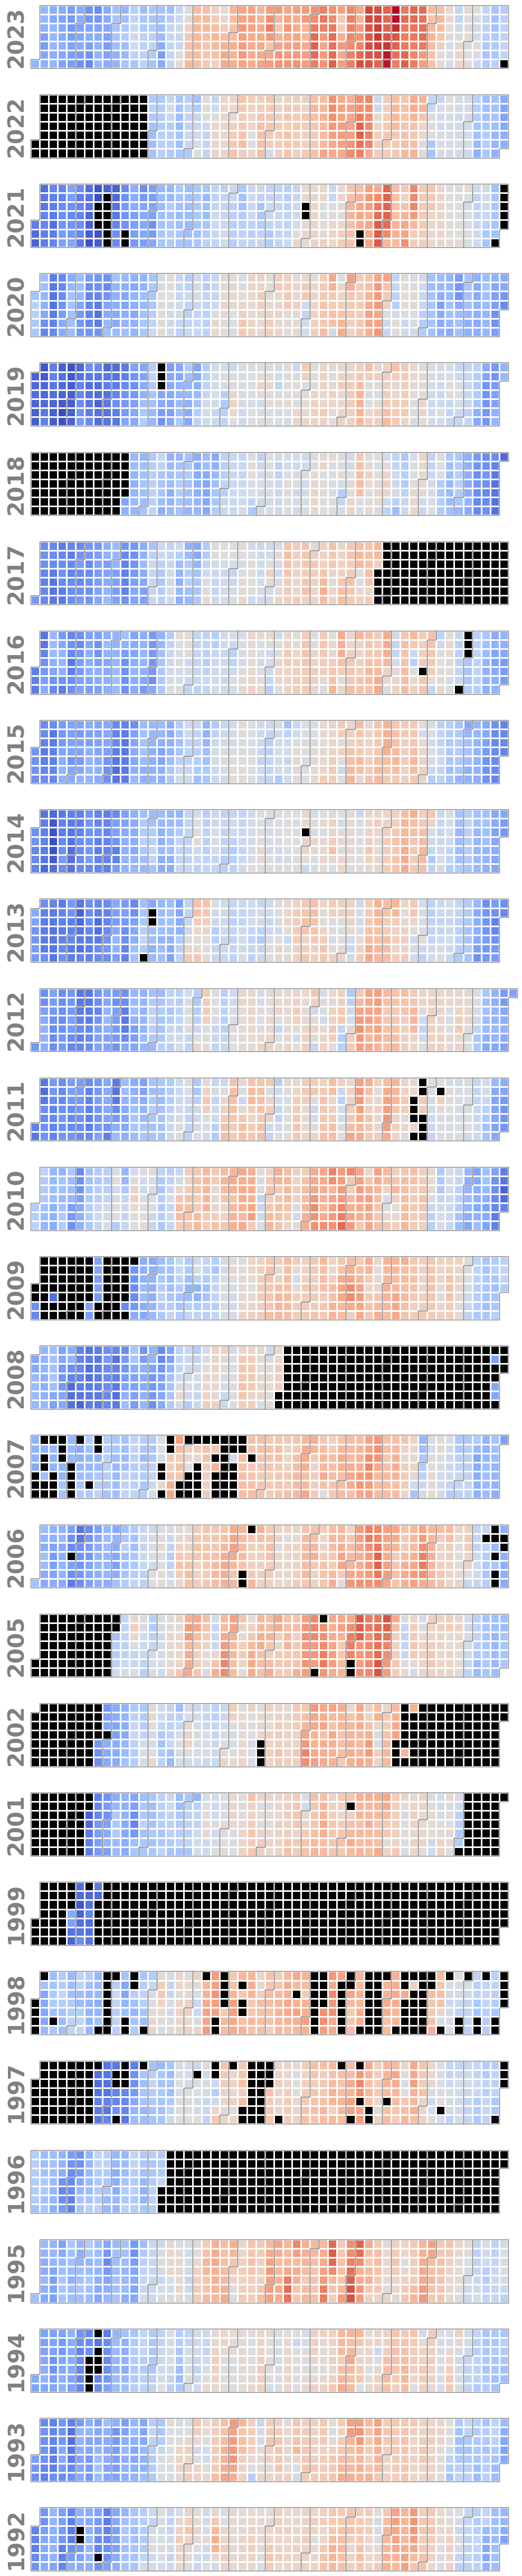

In [13]:
# @title Code to product cleaned final graphics as seen in the report
if station_choice == 'single':
    station_list = [station_selection]
for station in station_list:
    print(str(station))
    try:
        station_df = pd.read_csv(path+str(station)+'_final_daily_flagged.csv')
    except FileNotFoundError:
        print("file not found")
        continue
    station_clean = station_df.copy()
    try:
        station_clean.loc[station_clean['manual_flag'] == 1, 'DAILY_WATER_TEMP'] = np.nan
        station_clean.loc[station_clean['manual_flag'] == 1, 'residual'] = np.nan
    except KeyError:
        print('No manual flag for this station')
    try:
        station_clean.loc[station_clean['automated_flag'] == 1, 'DAILY_WATER_TEMP'] = np.nan
        station_clean.loc[station_clean['automated_flag'] == 1, 'residual'] = np.nan
    except KeyError:
        print('No automated flag for this station')

    date_range_complete = pd.date_range(start=station_clean.index.min(), end=station_clean.index.max(), freq='D')
    # Find missing dates
    missing_dates = date_range_complete.difference(station_clean.index)

    # If there are missing dates, we can add them to the DataFrame
    if len(missing_dates) > 0:
            print("Missing Timestamps:")
            print(missing_dates)

    # Create an empty DataFrame with the missing dates (no data associated with them)
    missing_df = pd.DataFrame(index=missing_dates)

    # Reindex the original station_df to include the missing dates
    station_clean = station_clean.reindex(station_clean.index.union(missing_dates))

    station_clean['Date'] = pd.to_datetime(station_clean['Date'])

    f1=plt.figure(figsize=(12,6))
    ax1 = f1.add_subplot(111)
    ax1.plot(station_clean['Date'],station_clean['DAILY_WATER_TEMP'],color='black')
    ax1.set_ylabel('Temperature (deg C)',fontsize= 16)
    ax1.set_xlabel('Years',fontsize=16)
    plt.title('Cleaned water temp for '+str(station),fontsize=18)
    ax1.tick_params(axis='x',labelsize=14)
    ax1.tick_params(axis='y',labelsize=14)
    fig_path=r'Daily_Water_Final_Plots/'+str(station)

    if not os.path.exists(fig_path):
        os.makedirs(fig_path)
    f1.tight_layout()
    f1.savefig(fname='Daily_Water_Final_Plots/'+str(station)+'/'+str(station)+'_daily_timeseries.png',dpi=300)

    station_clean['dayofyear'] = station_clean['Date'].dt.day_of_year
    seasonal_df = pd.DataFrame(station_clean['DAILY_WATER_TEMP'].groupby(station_clean['dayofyear']).mean())
    seasonal_sd = pd.DataFrame(station_clean['DAILY_WATER_TEMP'].groupby(station_clean['dayofyear']).std())

    seasonal_df['high'] = seasonal_df['DAILY_WATER_TEMP'] + 2*seasonal_sd['DAILY_WATER_TEMP']
    seasonal_df['low'] = seasonal_df['DAILY_WATER_TEMP'] - 2*seasonal_sd['DAILY_WATER_TEMP']

    f2=plt.figure(figsize=(12,6))
    ax2=f2.add_subplot(111)
    plt.title('Cleaned Seasonal Cycle for '+str(station),fontsize=18)
    ax2.plot(seasonal_df['DAILY_WATER_TEMP'],color='black',label='Seasonal Cycle')
    ax2.plot(seasonal_df['high'],color='black',linestyle='--',label='2 Standard Deviations')
    ax2.plot(seasonal_df['low'],color='black',linestyle='--')
    ax2.set_ylabel('Temperature (deg C)',fontsize = 16)
    ax2.set_xlabel('Days of Year', fontsize=16)
    ax2.legend(loc='best',fontsize=14,edgecolor='white')
    ax2.tick_params(axis='x',labelsize=14)
    ax2.tick_params(axis='y',labelsize=14)
    f2.tight_layout()
    f2.savefig(fname='Daily_Water_Final_Plots/'+str(station)+'/'+str(station)+'_seasonal.png',dpi=300)

    station_clean.index = station_clean.dayofyear

    station_clean['seasonal'] = seasonal_df['DAILY_WATER_TEMP']
    station_clean['high'] = seasonal_df['high']
    station_clean['low'] = seasonal_df['low']
    station_clean['year'] = station_clean['Date'].dt.year

    years = station_clean['year'].unique().tolist()
    years = [int(year) for year in years if not np.isnan(year)]
    station_clean.index = station_clean['Date']
    colors = plt.cm.Greys(np.linspace(0.4, 1, len(years)))[::-1]

    fig, ax = plt.subplots(figsize=(12,8))
    for i,year in enumerate(years):
        station_year = station_clean[station_clean['year']==year]
        station_year.index = station_year.dayofyear
        station_year = station_year.sort_index()
        all_days = pd.Index(range(1, 367))  # Days of the year from 1 to 366
        station_year = station_year.reindex(all_days)
        if year == 2023:
            ax.plot(station_year['dayofyear'],station_year['DAILY_WATER_TEMP'],linewidth=2.5,color='orange',label=year)
        else:
            linewidth = 1.5
            color = colors[i]
            ax.plot(station_year['dayofyear'],station_year['DAILY_WATER_TEMP'],color=color,linewidth=linewidth,label=year)

    ax.plot(seasonal_df['DAILY_WATER_TEMP'],linewidth=1.5,color='teal',label='Seasonal mean')
    ax.plot(seasonal_df['high'],linewidth=1.5,color='blue',label='2 Standard Deviations')
    ax.plot(seasonal_df['low'],linewidth=1.5,color='blue')
    ax.legend(loc='upper center', fontsize=14, edgecolor='white', bbox_to_anchor=(0.5, -0.15), ncol=6)
    ax.set_ylabel('Temperature (deg C)',fontsize = 16)
    ax.set_xlabel('Days of Year', fontsize=16)
    plt.title('Yearly Seasonal Cycle for '+str(station),fontsize=18)
    ax.tick_params(axis='x',labelsize=14)
    ax.tick_params(axis='y',labelsize=14)
    fig.tight_layout()
    fig.savefig(fname='/content/Daily_Water_Final_Plots/'+str(station)+'/'+str(station)+'_seasonal_years.png',dpi=300,bbox_inches='tight')

    f3=plt.figure(figsize=(12,6))
    ax3 = f3.add_subplot(111)
    ax3.axhline(color='black',linestyle='--')
    ax3.plot(station_clean['Date'],station_clean['residual'],color='blue')

    ax3.set_ylabel('Temperature (deg C)',fontsize = 16)
    ax3.set_xlabel('Years',fontsize = 16)
    plt.title('Cleaned water temp residual for '+str(station),fontsize = 18)
    fig_path=r'/content/Daily_Water_Final_Plots/'+str(station)
    if not os.path.exists(fig_path):
        os.makedirs(fig_path)
    f3.savefig(fname='/content/Daily_Water_Final_Plots/'+str(station)+'/'+str(station)+'_daily_residual.png')

    station_clean = station_clean.dropna(subset=['DAILY_WATER_TEMP'])
    station_clean.index=station_clean.Date
    fig, ax = calplot.calplot(station_clean['DAILY_WATER_TEMP'],
                          how=None,
                          cmap='coolwarm',
                          fillcolor='black',
                          colorbar=False,
                          yearascending=False,
                          dayticks=False,
                          monthticks=False,yearlabel_kws={'fontname':'sans-serif'})

    plt.savefig(fname='/content/Daily_Water_Final_Plots/'+str(station)+'/'+str(station)+'_heatmap.png')





## **Conclusions**

###Thank you for taking the time to walk through this Coastal Temperature Final Station Graphics Notebook

###This notebook is associated with the Evaluation and Quality Control of CO-OPS Coastal Water Temperature Data Technical Report and replicates some of the station-specific graphics available in the report with the QA/QCed daily temperature data.
